<a href="https://colab.research.google.com/github/Rayudu-Somisetty/deep_learning_lab_tasks/blob/main/Threshold_Activation_Function_%2B_Sigmoid_Activation_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

matplotlib.pyplot loaded: True
Initial Weights: [ 0.49671415 -0.1382643 ]
Initial Bias: 0.6476885381006925
Epoch   0 | Loss: 0.3670
Epoch  10 | Loss: 0.2969
Epoch  20 | Loss: 0.2517
Epoch  30 | Loss: 0.2244
Epoch  40 | Loss: 0.2067
Epoch  50 | Loss: 0.1939
Epoch  60 | Loss: 0.1839
Epoch  70 | Loss: 0.1753
Epoch  80 | Loss: 0.1678
Epoch  90 | Loss: 0.1610

Training Complete
Final Weights: [0.58639886 0.25170904]
Final Bias: -1.0460319277452834

Predictions
[0,0] -> Sigmoid:0.260 -> Threshold:0
[0,1] -> Sigmoid:0.311 -> Threshold:0
[1,0] -> Sigmoid:0.387 -> Threshold:0
[1,1] -> Sigmoid:0.448 -> Threshold:0


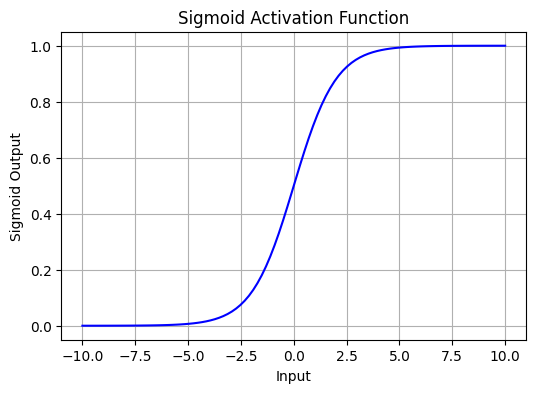

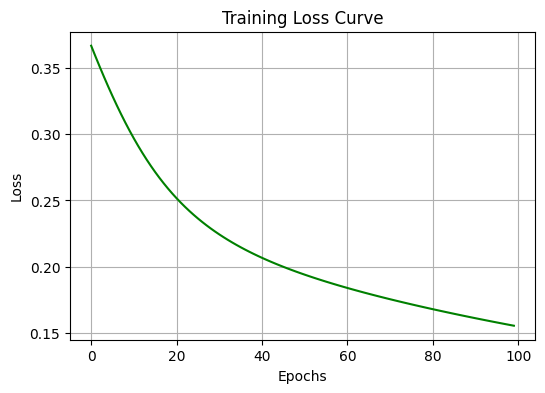

In [2]:
############
#
# Threshold Activation Function + Sigmoid Activation Function
#
############

### Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Debugging: Confirm matplotlib.pyplot is loaded
print(f"matplotlib.pyplot loaded: {plt is not None}")

### Create dataset (AND Gate example)
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [0],
              [0],
              [1]])

### Hyperparameters
learning_rate = 0.1
epochs = 100

### Initialize weights randomly
np.random.seed(42)
weights = np.random.randn(2,1)
bias = np.random.randn(1)

print("Initial Weights:", weights.flatten())
print("Initial Bias:", bias[0])

### Sigmoid activation function
def sigmoid(x):
    return 1/(1+np.exp(-x))

### Sigmoid derivative
def sigmoid_derivative(x):
    return x*(1-x)

### Threshold activation function
def threshold(x):
    return 1 if x >= 0.5 else 0

### Training using Sigmoid activation
loss_history = []

for epoch in range(epochs):

    # forward pass
    linear_output = np.dot(X, weights) + bias
    output = sigmoid(linear_output)

    # error
    error = y - output

    # loss (MSE)
    loss = np.mean(error**2)
    loss_history.append(loss)

    # backpropagation
    d_output = error * sigmoid_derivative(output)

    # gradients
    dW = np.dot(X.T, d_output)
    dB = np.sum(d_output)

    # update weights
    weights += learning_rate * dW
    bias += learning_rate * dB

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f}")

print("\nTraining Complete")
print("Final Weights:", weights.flatten())
print("Final Bias:", bias[0])

### Predictions
print("\nPredictions")

linear_values = np.dot(X, weights) + bias
sigmoid_output = sigmoid(linear_values)

for i in range(len(X)):
    pred_class = threshold(sigmoid_output[i][0])
    print(f"[{X[i,0]},{X[i,1]}] -> Sigmoid:{sigmoid_output[i][0]:.3f} -> Threshold:{pred_class}")

### Plot sigmoid function
x_vals = np.linspace(-10,10,100)
y_vals = sigmoid(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals, color='blue')
plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Sigmoid Output")
plt.grid(True)
plt.show()

### Plot loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_history, color='green')
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()